## **1. Introduction to Files**

> - Learning to work with files and save data will make your programs easier for people to use.
>
> - <span style="background:LemonChiffon">People will be able to run your program, do some work, and then close the program and pick up where they left off.
> - An incredible amount of data is available in text files. Text files can contain weather data, literary works, and more.
> - Reading from a file is particularly useful in data analysis, but it’s also applicable to any situation in which you want to analyze or modify information stored in a file.

### **Reading from a File**

> When you want to work with the information in a text file, <span style="background:LemonChiffon">the first step is to read the file into memory

#### **Reading the Contents of a File**

> - Let’s start with a file that contains pi to 30 decimal places, with 10 decimal places per line.
> - Here’s a program that **opens** this file, **reads** it, and **prints** the contents of the file to the screen:

In [1]:
from pathlib import Path

> - we need to tell Python the **path to the file**. A **path** is <span style="background:LemonChiffon">the exact location of a file or folder on a system.
>   
> - Python provides a module called **`pathlib`** that makes it easier to work with files, no matter which operating system you or your program’s users are working with.
     - Importing the **`Path`** class from **`pathlib`**
     - There’s a lot you can do with a **`Path`** object that points to a file. <span style="background:LemonChiffon">For example, you can check that the file exists before working with it, read the file’s contents, or write new data to the file.<br><br>
> - we build a `Path` object representing the file `pi_digits.txt`, which we assign to the variable `path`.
> - <span style="background:LemonChiffon">Since this file is saved in the same directory as this file we’re writing, the filename is all that `Path` needs to access the file.

In [3]:
path = Path('pi_digits.txt')
contents = path.read_text()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
print(contents)

3.1415926535
  8979323846
  2643383279



> - we use the **`read_text()`** method to read the entire contents of the file. <span style="background:LemonChiffon">
The contents of the file are returned as a single string, which we assign to the variable `contents`.
> - The only difference between this output and the original file is the extra blank line at the end of the output.
> - We can remove the extra blank line by using **`rstrip()`** on the contents string:

In [5]:
path = Path('pi_digits.txt')
contents = path.read_text()
contents = contents.rstrip()
print(contents)

3.1415926535
  8979323846
  2643383279


> - We can strip the newline character when we read the contents of the file, by applying the **`rstrip()`** method after calling **`read_text()`**:

In [7]:
contents = path.read_text().rstrip() # This approach is called method chaining

#### **Relative and Absolute File Paths**

> - When you pass a simple filename like `pi_digits.txt` to `Path`, Python looks in the directory where the file that’s currently being executed.
> - Sometimes, the file you want to open won’t be in the same directory as your program file.
> - Python will only look in "**Day07**" and stop there.
> - There are two main ways to specify paths:
    - <span style="background:palegreen">relative</span> file path tells Python to look for a given location relative to the directory where this running program file is stored.

In [29]:
path = Path('Lecture7_files/pi_digits_relative.txt')
contents = path.read_text().rstrip()
print(contents)

3.1415926535
  8979323846
  2643383279


> - To Python exactly where the file is on your computer, regardless of where the program that’s being executed is stored, this is the <span style="background:palegreen">absolute file path

In [11]:
path = Path("C:/Users/Mostafag/Desktop/Python for System Admin/pi_digits_abs.txt")
contents = path.read_text().rstrip()
print(contents)

3.1415926535
  8979323846
  2643383279


> - For now it’s easiest to store files in the same directory as your program files, or in a folder such as Lecture7_files within the directory that stores your program files.

#### 📝 **Note**
> - <span style="background:LavenderBlush">Windows systems use a **backslash (\\)** instead of a **forward slash (/)** when displaying file paths, but you should use forward slashes in your code, even on Windows. The `pathlib` library will automatically use the correct representation of the path when it interacts with your system, or any user’s system.</span>

#### **Accessing a File’s Lines**

> - You might want to read through a file of weather data and work with any line that includes the word *sunny* in the description of that day’s weather.
> - You can use the **`splitlines()`** method to <span style="background:LemonChiffon">return a long string into a set of lines, and then use a for loop to examine each line from a file, one at a time:</span>

In [13]:
path = Path('pi_digits.txt')
contents = path.read_text()
lines = contents.splitlines()

In [15]:
lines

['3.1415926535', '  8979323846', '  2643383279']

> - If you’re planning to work with the individual lines in a file, you don’t need to strip any whitespace when reading the file.
> - The **`splitlines()`** method returns a list of all lines in the file, and we assign this list to the variable lines.

In [ ]:
print(lines)

In [17]:
for line in lines:
    print(line)

3.1415926535
  8979323846
  2643383279


#### **Working with a File’s Contents**

> After you’ve read the contents of a file into memory, you can do whatever you want with that data.

In [19]:
pi_string = ''

for line in lines:
    pi_string += line
    
print(pi_string)
print(len(pi_string))

3.1415926535  8979323846  2643383279
36


> The variable `pi_string` contains the whitespace that was on the left side of the digits in each line, but we can get rid of that by using `lstrip()` on each line:

In [21]:
pi_string = ''

for line in lines:
    pi_string += line.lstrip()
    
print(pi_string)
print(len(pi_string))

3.141592653589793238462643383279
32


#### 📝 **Note**
> - <span style="background:LavenderBlush">When Python reads from a text file, it interprets all text in the file as a string. If you read in a number and want to work with that value in a numerical context, you’ll have to convert it to an integer using the `int()` function or a float using the `float()` function.

#### **Large Files: One Million Digits**

> - So far, we’ve focused on analyzing a text file that contains only three lines, but the code in these examples would work just as well on much larger files.
> - Python has no inherent limit to how much data you can work with; you can work with as much data as your system’s memory can handle.

In [23]:
path = Path('pi_million_digits.txt')

contents = path.read_text()
lines = contents.splitlines()

pi_string = ''

for line in lines:
    pi_string += line.lstrip()
    
print(f"{pi_string[:50]}...")
print(len(pi_string))

3.141592653589793238462643383279502884197169399375...
1000002


### **Writing to a File**

> - One of the simplest ways to save data is to write it to a file. When you write text to a file, the output will still be available after you close the program.
> - You can also write programs that read the text back into memory and work with it again later.

#### **Writing a Single Line**

> - Once you have a path defined, you can write to a file using the **`write_text()`** method.
> - The `write_text()` method takes a single argument: the string that you want to write to the file.

In [31]:
path = Path('programming.txt')
path.write_text("I love programming.")

19

#### 📝 **Note**
> - <span style="background:LavenderBlush">Python can only write strings to a text file. If you want to store numerical data 
in a text file, you’ll have to convert the data to string format first using the **`str()`** function.

#### **Writing Multiple Lines**

> - The **`write_text()`** method does a few things behind the scenes:
>   
>    - If the file that path points to doesn’t exist, it creates that file.
>    - Also, after writing the string to the file, it makes sure the file is closed properly. Files that aren’t closed properly can lead to missing or corrupted data.<br><br>
> - To write more than one line to a file, you need to build a string containing the entire contents of the file.
> - In this case we include newline characters at the end of each line, to make sure each statement appears on its own line.

In [33]:
contents = "I love Python.\n"
contents += "I love creating new games.\n"
contents += "I also love working with data.\n"

path = Path('programming.txt')
path.write_text(contents)

73

#### 📝 **Note**
> <span style="background:LavenderBlush">Be careful when calling **`write_text()`** on a path object. If the file already exists, **`write_text()`** will erase the current contents of the file and write new contents to the file.<br>
> - If you want to append?<br>
> `with my_path.open("a") as f:
    f.write("")`

#### ✍🏻 **TRY IT YOURSELF**
> **Guest:** Write a program that prompts the user for their name. When they respond, write their name to a file called guest.txt.

### **Exceptions**

> - Python uses special objects called **exceptions** to manage errors that arise during a program’s execution. Whenever an error occurs that makes Python unsure of what to do next, it creates an exception object.
> - If you write code that handles the exception, the program will continue running.
> -  If you don’t handle the exception, the program will halt and show a *traceback*, which includes a report of the exception that was raised.

### **Exceptions Handling**

> - Exceptions are handled with **try-except** blocks.
> - <span style="background:LemonChiffon">A **try-except** block asks Python to do something, but it also tells Python what to do if an exception is raised.
> - <span style="background:LemonChiffon">When you use **try-except** blocks, your programs will continue running even if things start to go wrong.
> - <span style="background:LemonChiffon">Instead of **tracebacks**, which can be confusing for users to read, users will see friendly error messages that you’ve written.

#### **Handling the ZeroDivisionError Exception**

> Let’s look at a simple error that causes Python to raise an exception. 

In [37]:
print(5/0)
print("Hello")

ZeroDivisionError: division by zero

> - Python stops the program and tells us the kind of exception that was raised.
> - We’ll tell Python what to do when this kind of exception occurs; that way, if it happens again, we’ll be prepared.

#### **Using try-except Blocks**

> <span style="background:LemonChiffon">When you think an error may occur, you can write a try-except block to handle the exception that might be raised.

In [39]:
try:
    print(5/0)
except ZeroDivisionError:
    print("You can't divide by zero!")

You can't divide by zero!


> - We put `print(5/0)`, the line that caused the error, inside a `try` block.
> - If the code in a `try` block works, Python skips over the `except` block.
> - If the code in the `try` block causes an error, Python looks for an `except` block whose error matches the one that was raised, and runs the code in that block.

> - Python then runs the code in that block, and <span style="background:LemonChiffon">the user sees a friendly error message instead of a traceback.
> - If more code followed the try-except block, the program would continue running because we told Python how to handle the error. 

#### **Using Exceptions to Prevent Crashes**

> - Handling errors correctly is especially important when the program has more work to do after the error occurs. <span style="background:LemonChiffon">This happens often in programs that prompt users for input.
> - If the program responds to invalid input appropriately, it can prompt for more valid input instead of crashing.
> - This program does nothing to handle errors, so asking it to divide by zero causes it to crash.

In [41]:
print("Give me two numbers, and I'll divide them.")
print("Enter 'q' to quit.")

while True:
    first_number = input("\nFirst number: ")
    if first_number == 'q':
        break
        
    second_number = input("Second number: ")
    if second_number == 'q':
        break
        
    answer = int(first_number) / int(second_number)
    
    print(answer)

Give me two numbers, and I'll divide them.
Enter 'q' to quit.



First number:  10
Second number:  0


ZeroDivisionError: division by zero

In [43]:
int("Hello")

ValueError: invalid literal for int() with base 10: 'Hello'

> - Nontechnical users will be confused by them, and in a malicious setting, attackers will learn more than you want them to.
> - For example, they’ll know the name of your program file, and they’ll see a part of your code that isn’t working properly.
> - A skilled attacker can sometimes use this information to determine which kind of attacks to use against your code.

#### **The else Block**

> The error occurs on the line that performs the division, so that’s where we’ll put the **try-except** block.

In [45]:
print("Give me two numbers, and I'll divide them.")
print("Enter 'q' to quit.")

while True:
    first_number = input("\nFirst number: ")
    if first_number == 'q':
        break
        
    second_number = input("Second number: ")
    if second_number == 'q':
        break
    try:    
        answer = int(first_number) / int(second_number)
        print(answer)
    except ZeroDivisionError:
        print("You can't divide by 0!")

Give me two numbers, and I'll divide them.
Enter 'q' to quit.



First number:  10
Second number:  0


You can't divide by 0!



First number:  yomna
Second number:  10


ValueError: invalid literal for int() with base 10: 'yomna'

> This example also includes an `else` block. Any code that depends on the `try` block executing successfully goes in the `else` block:

In [49]:
print("Give me two numbers, and I'll divide them.")
print("Enter 'q' to quit.")

while True:
    first_number = input("\nFirst number: ")
    if first_number == 'q':
        break
        
    second_number = input("Second number: ")
    if second_number == 'q':
        break
        
    try:    
        answer = int(first_number) / int(second_number)
    except ZeroDivisionError:
        print("You can't divide by 0!")
    except ValueError:
        print("you only can enter a number")
    else:    
        print(answer)

Give me two numbers, and I'll divide them.
Enter 'q' to quit.



First number:  hello
Second number:  10


you only can enter a number



First number:  hello
Second number:  0


you only can enter a number



First number:  q


> - The only code that should go in a `try` block is code that might cause an exception to be raised.
> - Sometimes you’ll have additional code that should run only if the `try` block was successful; this code goes in the `else` block. 
> - The `except` block tells Python what to do in case a certain exception arises when it tries to run the code in the `try` block.

#### ✍🏻 **TRY IT YOURSELF**
> Write a function named **`readposint`** that uses the input dialog to prompt the user for a positive integer and then checks the input to confirm that it meets the requirements. It should be able to handle inputs that:
> - Cannot be converted to int.
> - Negative int.
> - Edge cases (e.g. when the user closes the dialog, or does not enter anything at all.)

#### **Handling the FileNotFoundError Exception**

> - One common issue when working with files is handling missing files.
> - The file you’re looking for might be in a different location, the filename might be misspelled, or the file might not exist at all. You can handle all of these situations with a **try-except** block.

In [53]:
path = Path('alice.txt')
contents = path.read_text(encoding='utf-8')
print(contents)

FileNotFoundError: [Errno 2] No such file or directory: 'alice.txt'

> - It’s often best to start at the very end of the **traceback**. On the last line, we can see that a `FileNotFoundError` exception was raised.
> - This is important because it tells us what kind of exception to use in the `except` block that we’ll write.
> - The `try` block will begin with the line that was identified as problematic in the traceback. In our example, 
this is the line that contains **`read_text()`**:

In [57]:
path = Path('alice.txt')
try:
     contents = path.read_text(encoding='utf-8')
except FileNotFoundError:
     print(f"Sorry, the file {path} does not exist.")
else:
    print(contents)

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Alice's Adventures in Wonderland

Author: Lewis Carroll

Release date: June 27, 2008 [eBook #11]
                Most recently updated: November 10, 2024

Language: English

Credits: Arthur DiBianca and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***
[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Te

> The program has nothing more to do if the file doesn’t exist, so this is all the output we see. Let’s build on this example and see how exception handling can help when you’re working with more than one file.

#### **Analyzing Text**

> Let’s pull in the text of *Alice in Wonderland* and try to count the number of words in the text. To do this, we’ll use the string method **`split()`**, <span style="background:LemonChiffon">which by default splits a string wherever it finds any whitespace:

In [59]:
path = Path('alice.txt')

try:
    contents = path.read_text(encoding='utf-8')
except FileNotFoundError:
    print(f"Sorry, the file {path} does not exist.")
else:
     # Count the approximate number of words in the file:
     words = contents.split()
     num_words = len(words)
     print(f"The file {path} has about {num_words} words.")

The file alice.txt has about 29573 words.


> - I moved the file alice.txt to the correct directory, so the try block will 
work this time.
> - Use **`split()`** to produce a list of all the words in the book.
> - Using **`len()`** on this list to gives us a good approximation of the number of words in the original text.
> - This code is placed in the `else` block because it only works if the code in the `try` block was executed successfully.

#### **Working with Multiple Files**

> Let’s add more books to analyze, but before we do, let’s move the bulk of this program to a function called `count_words()`. This will make it easier to run the analysis for multiple books:

In [61]:
def count_words(path):
    """Count the approximate number of words in a file."""
    try:
        contents = path.read_text(encoding='utf-8')
    except FileNotFoundError:
        print(f"Sorry, the file {path} does not exist.")
    else:
        words = contents.split()
        num_words = len(words)
        print(f"The file {path} has about {num_words} words.")

path = Path('alice.txt')
count_words(path)

The file alice.txt has about 29573 words.


> The `encoding` argument is needed when your system’s default encoding doesn’t match the encoding of the file that’s being read. 
This is most likely to happen when reading from a file that wasn’t created on your system.

> Most of this code is unchanged. It’s only been indented, and moved into the body of `count_words()`. It’s a good habit to keep comments up to date when you’re modifying a program, so the comment has also been changed to a **docstring** and reworded slightly

In [63]:
filenames = ['alice.txt', 'little_women.txt', 'scarlet_letter.txt', 'the_prince.txt']

for filename in filenames:
     path = Path(filename)
     count_words(path)

The file alice.txt has about 29573 words.
Sorry, the file little_women.txt does not exist.
The file scarlet_letter.txt has about 86878 words.
The file the_prince.txt has about 52983 words.


> Each string is then converted to a `Path` object, before the call to `count_words()`. The missing 
*little_women.txt* file has no effect on the rest of the program’s execution:

> - Using the **try-except** block in this example provides two significant advantages:
>    - We prevent our users from seeing a traceback.
>    - We let the program continue analyzing the texts it’s able to find.<br><br>
> - If we don’t catch the `FileNotFoundError` that little_women.txt raises, the user would see a full traceback, and the program would stop running after trying to analyze *little_women*. It would never analyze *scarlet_letter* or *the_prince*.

#### **Failing Silently**

> - In the previous example, we informed our users that one of the files was unavailable.
> - But you don’t need to report every exception you catch. 
> - Sometimes, you’ll want the program to fail silently when an exception occurs and continue on as if nothing happened.
> - you write a `try` block as usual, <span style="background:LemonChiffon">but you explicitly tell Python to do nothing in the `except` block. Python has a **`pass`** statement that tells it to do nothing in a block:


In [65]:
def count_words(path):
    """Count the approximate number of words in a file."""
    try:
        contents = path.read_text(encoding='utf-8')
    except FileNotFoundError:
        pass
    else:
        # Count the approximate number of words in the file:
        words = contents.split()
        num_words = len(words)
        print(f"The file {path} has about {num_words} words.")

In [67]:
filenames = ['alice.txt', 'little_women.txt', 'scarlet_letter.txt', 'the_prince.txt']

for filename in filenames:
     path = Path(filename)
     count_words(path)

The file alice.txt has about 29573 words.
The file scarlet_letter.txt has about 86878 words.
The file the_prince.txt has about 52983 words.


> - <span style="background:LemonChiffon">No traceback is produced,</span> and there’s <span style="background:LemonChiffon">no output in response to the error</span> that was raised.
> - Users see the word counts for each file that exists, but they don’t see any indication that a file wasn’t found.
> - The **`pass`** statement also acts as a **placeholder**. <span style="background:LemonChiffon">
It’s a reminder that you’re choosing to do nothing at a specific point in your program’s execution and that you might want to do something there later. For example, in this program we might decide to write any missing filenames to a file called *missing_files.txt.*

#### **Deciding Which Errors to Report**

> - <span style="background:LavenderBlush">How do you know when to report an error to your users and when to let your program fail silently?
>     - If users know which texts are supposed to be analyzed, they might appreciate a message informing them why some texts 
were not analyzed.
>     - If users expect to see some results but don’t know which books are supposed to be analyzed, they might not need to know that some texts were unavailable.<br><br>
>
> - Python’s error-handling structures give you fine-grained control over how much to share with users when things go wrong; it’s up to you to decide how much information to share.
> - Well-written, properly tested code is not very prone to internal errors, such as **syntax** or **logical errors**.
> - <span style="background:LemonChiffon">But every time your program depends on something external such as user input, the existence of a file, or the availability of a network connection, there is a possibility of an exception being raised. 

#### **Principles for using Exceptions**

> - If a condition can be handled using the normal flow-of-control, don’t use an exception!

#### **Example (1)**

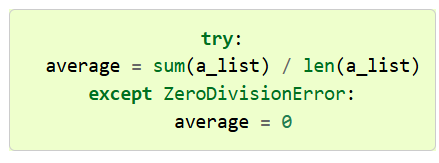

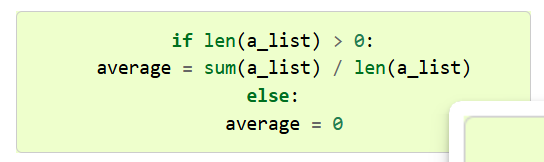

#### **Example (2)**

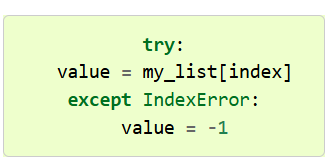

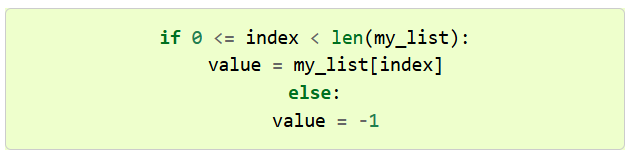

#### **Example (3)**

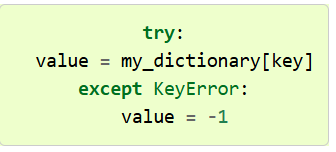

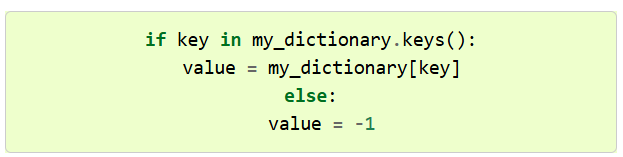

### 📘**Reading**

> - Read about the **`exists()`** method.
> - Json files.
> - https://programming-24.mooc.fi/part-6

### 📘**Resources**

> - Python Crash Course, 3rd Edition by Eric Matthes.
> - How to Think Like a Computer Scientist.